# Preliminary

For grading purposes, please answer the following:
1. Are you a post-quals Math PhD student?
2. Are you intending to be graded according to the "heavy load" or "light load" grading scheme, as described in the syllabus?

As a reminder, the default is for post-quals Math students to be graded according to the light load and all others to be graded according to the heavy load. Please describe here or discuss with the instructor if you feel that an exception should be made in your case. 

1. No
2. "Heavy load"

# Mathematical exercises

Solutions to the following exercises may be either typed into the submitted Jupyter notebook, or handwritten solutions may be scanned and submitted as a separate PDF file.

1. Exercise 1.6 from the PRML textbook (3 points).
2. Exercise 1.12 from the PRML textbook (3 points).

# Coding exercises

In class, we generated some fake data and fit polynomials to the data. We noticed that higher-order polynomials did a good job of fitting the data, but a poor job of fitting new data that was generated in the same way. This is an example of **overfitting**.

In this assignment, we will use **cross validation** to combat overfitting by selecting a model that optimally describes data that was *not* used to fit the model.

Reminder: Once your notebook is complete, you should restart the kernel, run all of the cells in order, and make sure that no errors occur. Notebooks that run successfully without errors will be awarded one extra credit point.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

First, as we did in class, let's make some fake data.


Text(0, 0.5, 'y')

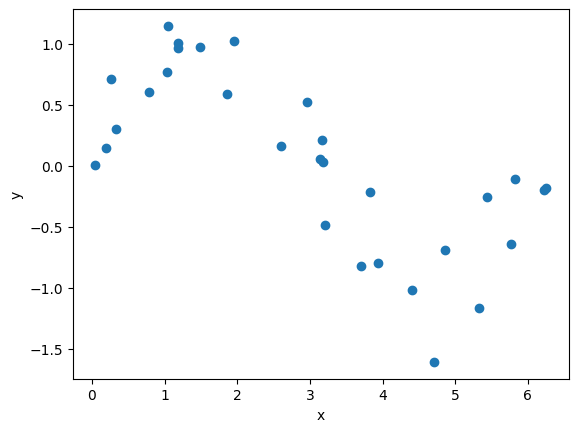

In [2]:
n = 30  # number of data points

# Simulated data:
x_data = 2*np.pi*np.random.rand(n)
noise_amp = 0.3
noise = noise_amp*np.random.randn(n)
y_data = np.sin(x_data) + noise

plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')

In class, we used the function `np.polyfit()` to fit the data with a polynomial:
$$
\hat{y} = \beta_0 + \beta_1 x + \ldots + \beta_{p-1} x^{p-1}
$$

In [3]:
# A polynomial fit:
p = 12
fit = np.polyfit(x_data, y_data, p)
beta_list = fit[::-1]  # flip the list so that it starts with beta0
print('Polynomial coefficients: \n', beta_list)


# The following function gives us the y value of our fitting curve given the x value:
def yhat(x, beta_list):
    '''
    Given the x value and the list of polynomial coefficients, return the y value.
    '''
    y = 0
    for p in range(len(beta_list)):
        y = y + beta_list[p]*x**p
        
    return y

Polynomial coefficients: 
 [-3.69898144e-01  8.68497248e+00 -3.81457691e+01  8.34218744e+01
 -1.00697830e+02  7.46028390e+01 -3.62005755e+01  1.18930897e+01
 -2.67001610e+00  4.04036398e-01 -3.94290266e-02  2.24077866e-03
 -5.63284164e-05]


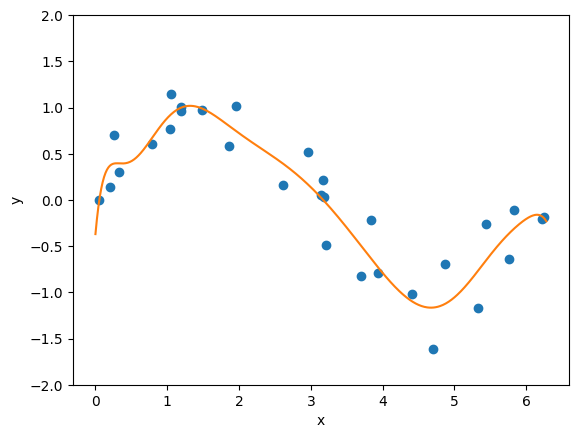

In [4]:
# Plot the data together with the fit.

x_pts = np.arange(0,2*np.pi,0.01)
y_fit = yhat(x_pts, beta_list)

plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x_pts, y_fit)
plt.ylim(-2,2);

How do we decide how good a fit like this is? To do this, we can use the mean squared error, which is the average squared distance between the data points and the curve at each x value in the dataset:
$$
\mathrm{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}(x_i))^2,
$$
where $(x_i, y_i)$ denotes one of the data points, and $\hat{y}(x)$ is the curve that fits the data. If the MSE is close to zero, then the curve is doing a good job of fitting the data.

**Exercise 1** (3 points): Create a function `mse(x, y, p)` that fits a polynomial of order `p` to data `x` and `y` and returns the mean squared error from the fit.

In [5]:
## Solution ##
def mse(x,y,p):
    if len(x) != len(y):
        raise ValueError("Input arrays must have the same length")
    n = len(x)
    fit = np.polyfit(x, y, p)
    beta_list = fit[::-1]  # flip the list so that it starts with beta0
    yhats = yhat(x, beta_list)
    return sum((y[i] - yhats[i])**2 for i in range(n)) / n


**Exercise 2** (3 points): For the data that we generated above, make a plot of the MSE for different values of $p$. Make sure to label the axes appropriately. You should find that the MSE decreases as $p$ increases.

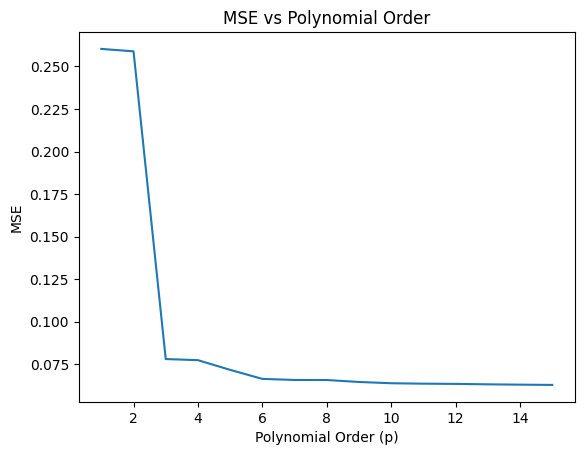

In [6]:
## Solution ##
polys = range(1, 16)
mse_data = [mse(x_data, y_data, p) for p in polys]

plt.plot(polys, mse_data)
plt.xlabel('Polynomial Order (p)')
plt.ylabel('MSE')
plt.title('MSE vs Polynomial Order')
plt.show()


In class, we found that, although higher-order polynomials may fit the data very well, they typically won't do a great job at describing new data that was not used for the fit. The idea of **cross validation** is to split the data into a **training set** and a **testing set**. The training set is used for fitting, and the testing set is used to quantify the goodness of the fit.

**Exercise 3** (5 pts): Create a new version of the function from the previous exercise. Call this function `mse_cv(x, y, p)`, which takes the same arguments as before. In this version, use the first half of the `x` and `y` data to perform the fit with a polynomial of order `p`. Compute the MSE using this first half of the data (the "training set"), then separately compute the MSE using the "held out" second half of the data (the "testing set"). Have the function return both MSE values. Finally, make a plot showing both the training MSE and the testing MSE for different values of $p$, using a legend to show which curve is which, and report the order of the polynomial that gives the optimal fit using cross-validation.

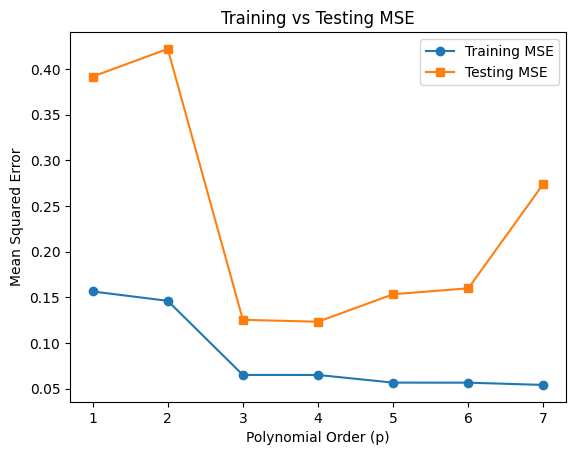

Optimal polynomial order using cross-validation: 4


In [ ]:
## Solution ##
def mse_cv(x, y, p):

    n = len(x)
    mid = n // 2

    x_train, x_test = x[:mid], x[mid:]
    y_train, y_test = y[:mid], y[mid:]

    # fit polynomial on training half
    coeff = np.polyfit(x_train, y_train, p)

    # predictions
    y_train_pred = np.polyval(coeff, x_train)
    y_test_pred  = np.polyval(coeff, x_test)

    # MSEs
    mse_train = np.mean((y_train - y_train_pred) ** 2)
    mse_test  = np.mean((y_test  - y_test_pred)  ** 2)

    return mse_train, mse_test


p_values = range(1, 8)
train_mse_list = []
test_mse_list = []

for p in p_values:
    train_mse, test_mse = mse_cv(x_data, y_data, p)
    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)

# Plot both training and testing MSE
plt.plot(p_values, train_mse_list, 'o-', label='Training MSE')
plt.plot(p_values, test_mse_list, 's-', label='Testing MSE')
plt.xlabel('Polynomial Order (p)')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Testing MSE')
plt.legend()
plt.show()

# Report optimal polynomial order
optimal_p = list(p_values)[int(np.argmin(test_mse_list))]
print("Optimal polynomial order using cross-validation:", optimal_p)


**Exercise 4**: AI-Guided Real Dataset Analysis with Cross-Validation (10 points)

Using an AI assistant (such as ChatGPT, Claude, or similar), complete the following analysis on a real dataset.

**(a)**: Dataset Selection (2 points)

Work with an AI assistant to identify and obtain a real-world dataset suitable for polynomial regression. The dataset should have:
- At least 50 observations
- A continuous response variable
- A clear relationship to investigate

In your submission, include:
1. A brief summary of your conversation with the AI
2. The source and URL (if applicable) of your chosen dataset
3. A brief description of the dataset (what the variables represent, context, etc.)
4. Code to load the dataset and display the first few rows

**(b)**: Exploratory Analysis (2 points)

Use the AI to help you:
1. Create at least one visualization showing the relationship between your chosen variables
2. Identify any data quality issues or preprocessing needs
3. Prepare the data for analysis (handle missing values, select relevant variables, etc.)

In your submission, include:
- The visualization(s) with proper labels and titles
- A brief description of any preprocessing steps taken
- Note any specific suggestions the AI provided that you found helpful

**(c)**: K-Fold Cross-Validation Implementation (3 points)

Extend the `mse_cv` function from Exercise 3 to implement **k-fold cross-validation**. Have the AI assist you in:
- Understanding how k-fold cross-validation works conceptually
- Implementing the algorithm
- Testing your implementation

Requirements:
- Write a function `mse_kfold(x, y, p, k=5)` that performs k-fold cross-validation
- The function should return both the average training MSE and average validation MSE across all k folds

**(d)**: Analysis and Interpretation (3 points)

Apply your k-fold cross-validation to the real dataset to determine the optimal polynomial order:

1. Test polynomial orders from 1 to 10 (or higher if needed)
2. Create a plot showing training MSE vs. validation MSE for different polynomial orders
3. Identify and clearly mark the optimal polynomial order on your plot

Write a brief analysis addressing:
- What polynomial order was optimal and why
- How the real dataset results compare to the synthetic data from Exercises 1-3
- Any insights from your AI conversations that helped your interpretation



I used Chat GPT-5.2 to help find my dataset

California Housing Dataset -  Each row corresponds to a California housing district. We will model median house value (`MedHouseVal`) as a function of median income (`MedInc`).

Source / reference: scikit-learn built-in dataset (originally from the 1990 California census)
- https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset


4(b): Exploratory Analysis + Preprocessing

 $x$: `MedInc` (median income, in tens of thousands of dollars)
 $y$: `MedHouseVal` (median house value, in $100,000s)

Things I did (w/ help from GPT 5)
- scatter plot to see relationship
- Check for missing values 
- Convert the chosen columns into NumPy arrays for the regression code

In [ ]:
import io
import ssl
import tarfile
import urllib.request
import certifi

FIGSHARE_URL = "https://ndownloader.figshare.com/files/5976036"
ctx = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(FIGSHARE_URL, context=ctx) as r:
    raw = r.read()
with tarfile.open(fileobj=io.BytesIO(raw), mode="r:gz") as tf:
    member = next(m for m in tf.getmembers() if m.name.endswith("cal_housing.data"))
    data = tf.extractfile(member).read()

raw_column_names = [
    "Longitude", "Latitude", "HouseAge", "TotalRooms", "TotalBedrooms",
    "Population", "Households", "MedInc", "MedHouseVal_dollars"
]
df = pd.read_csv(io.BytesIO(data), header=None, names=raw_column_names)
df["MedHouseVal"] = df["MedHouseVal_dollars"] / 100000.0
df = df.drop(columns=["MedHouseVal_dollars"])

display(df.head())

,Longitude,Latitude,HouseAge,TotalRooms,TotalBedrooms,Population,Households,MedInc,MedHouseVal
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,4.526
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3.585
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3.521
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3.413
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3.422


4(b) Exploratory Analysis: scatter plot and preprocessing

In [65]:
print("Missing values per column:")
print(df.isna().sum())
print()

Missing values per column:
Longitude        0
Latitude         0
HouseAge         0
TotalRooms       0
TotalBedrooms    0
Population       0
Households       0
MedInc           0
MedHouseVal      0
dtype: int64



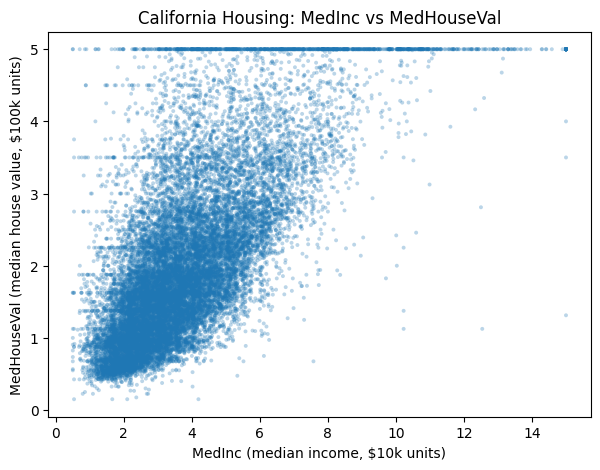

In [66]:
# Scatter plot of MedInc vs MedHouseVal
plt.figure(figsize=(7, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], s=8, alpha=0.3, edgecolors='none')
plt.xlabel("MedInc (median income, $10k units)")
plt.ylabel("MedHouseVal (median house value, $100k units)")
plt.title("California Housing: MedInc vs MedHouseVal")
plt.show()


In [79]:
x = df["MedInc"].to_numpy()
y = df["MedHouseVal"].to_numpy()
len(x)

20640

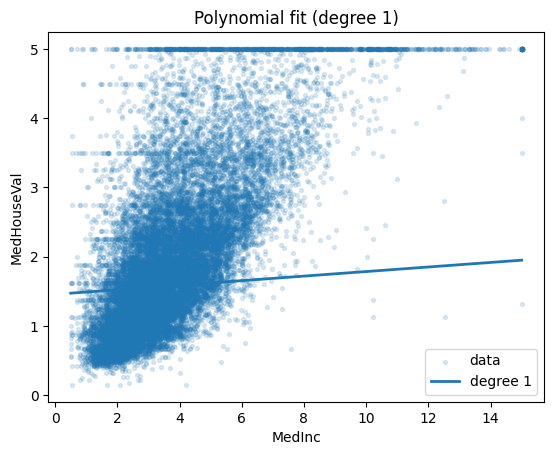

In [80]:
p = 1
fit = np.polyfit(x, y, p)
x_grid = np.linspace(x.min(), x.max(), 500)
y_fit = np.polyval(fit, x_grid)

plt.figure()
plt.scatter(x, y, alpha=0.15, s=8, label="data")
plt.plot(x_grid, y_fit, linewidth=2, label=f"degree {p}")
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title(f"Polynomial fit (degree {p})")
plt.legend()
plt.show()

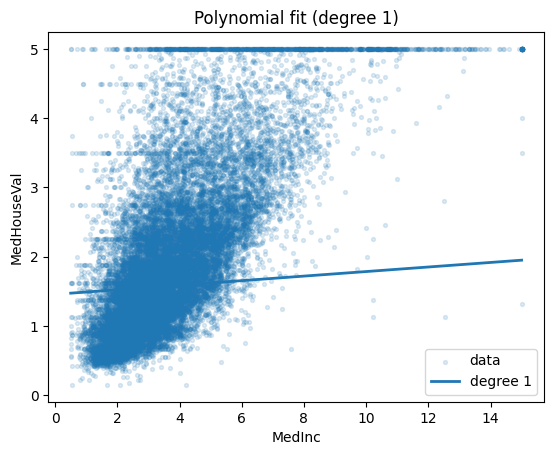

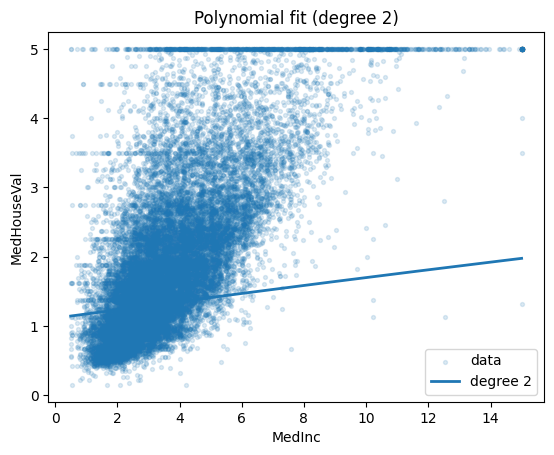

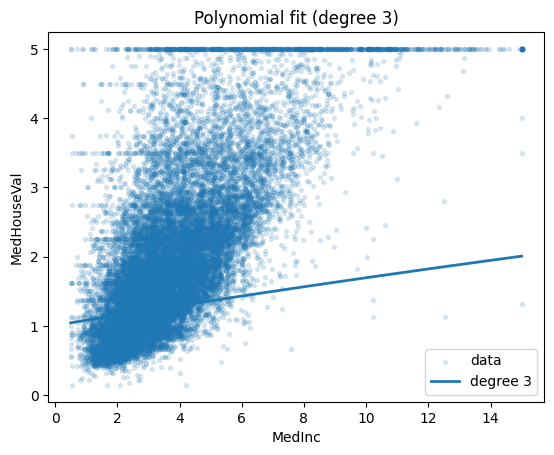

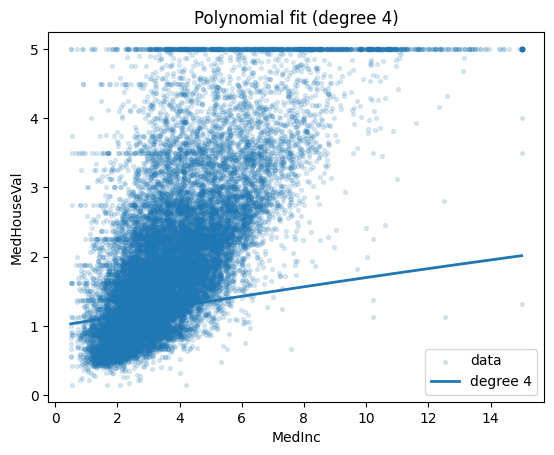

In [69]:
import numpy as np
import matplotlib.pyplot as plt

x = df["MedInc"].to_numpy(dtype=float)
y = df["MedHouseVal"].to_numpy(dtype=float)

idx = np.argsort(x)
x = x[idx]
y = y[idx]

for p in range(1,5):
    fit = np.polyfit(x, y, p)
    x_grid = np.linspace(x.min(), x.max(), 500)
    y_fit = np.polyval(fit, x_grid)

    plt.figure()
    plt.scatter(x, y, alpha=0.15, s=8, label="data")
    plt.plot(x_grid, y_fit, linewidth=2, label=f"degree {p}")
    plt.xlabel("MedInc")
    plt.ylabel("MedHouseVal")
    plt.title(f"Polynomial fit (degree {p})")
    plt.legend()
    plt.show()


chat GPT suggested scaling to help the polyfit algorithm work better for larger fits

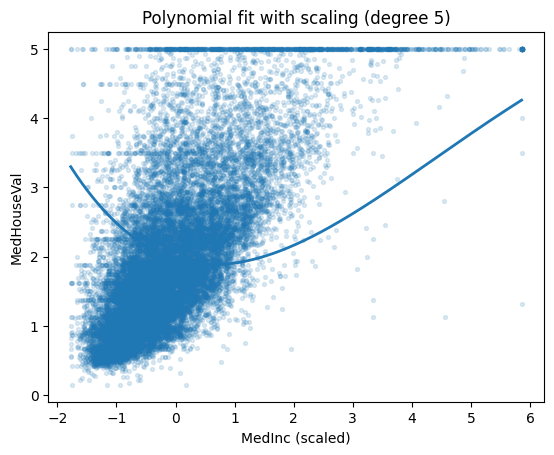

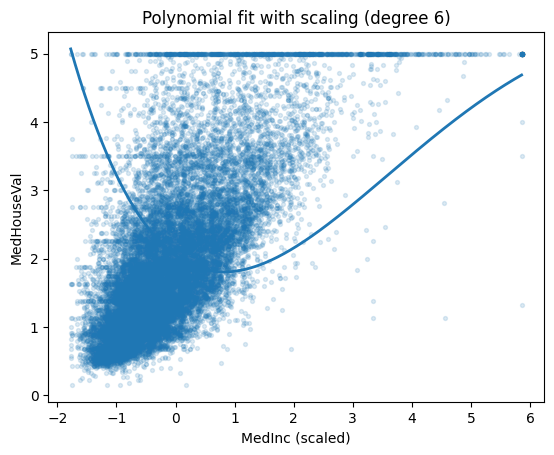

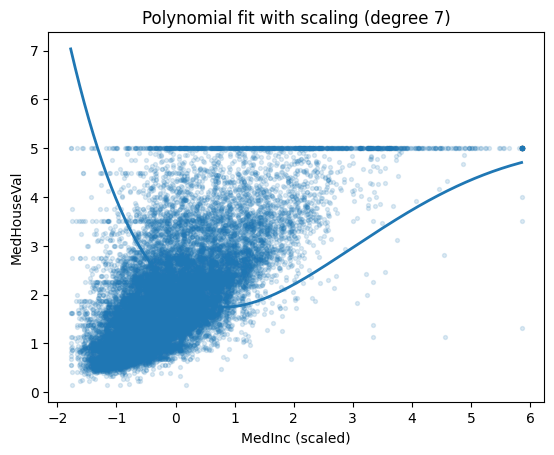

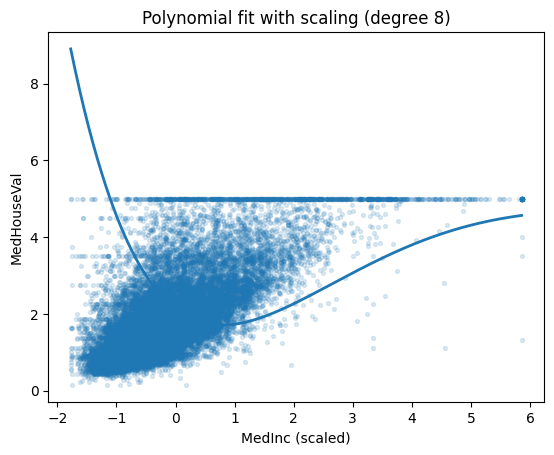

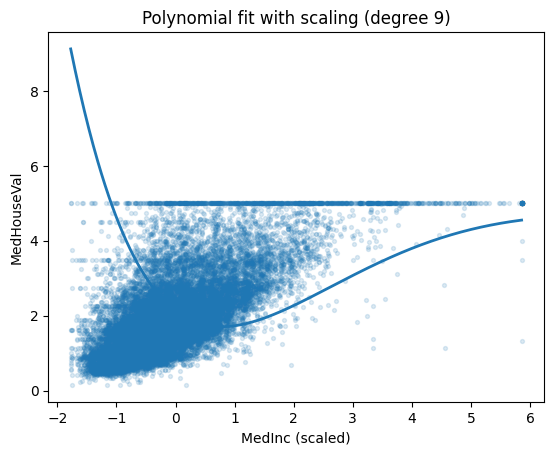

In [70]:
x = df["MedInc"].to_numpy(dtype=float)
y = df["MedHouseVal"].to_numpy(dtype=float)

# scale x (mean 0, std 1)
x_mean = x.mean()
x_std = x.std()
x_scaled = (x - x_mean) / x_std

# sort for plotting
idx = np.argsort(x_scaled)
x_scaled = x_scaled[idx]
y = y[idx]

for p in range(5,10):
    fit = np.polyfit(x_scaled, y, p)

    xg = np.linspace(x_scaled.min(), x_scaled.max(), 500)
    yg = np.polyval(fit, xg)

    plt.scatter(x_scaled, y, alpha=0.15, s=8)
    plt.plot(xg, yg, linewidth=2)
    plt.xlabel("MedInc (scaled)")
    plt.ylabel("MedHouseVal")
    plt.title(f"Polynomial fit with scaling (degree {p})")
    plt.show()


There is a cap on median house value at 5.0, so I got rid of these maximums to see how the fit would perform:

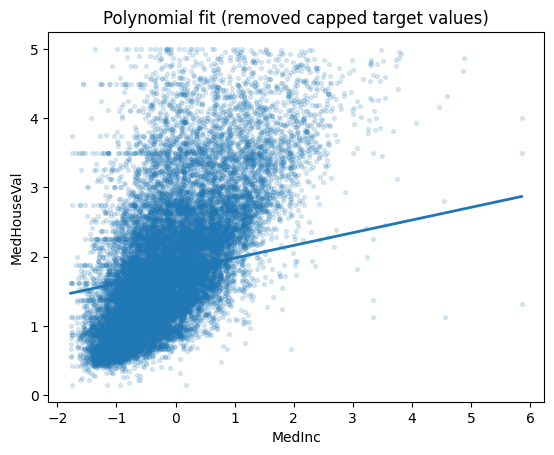

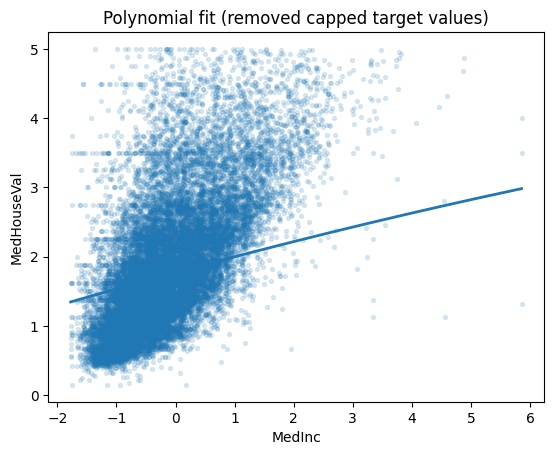

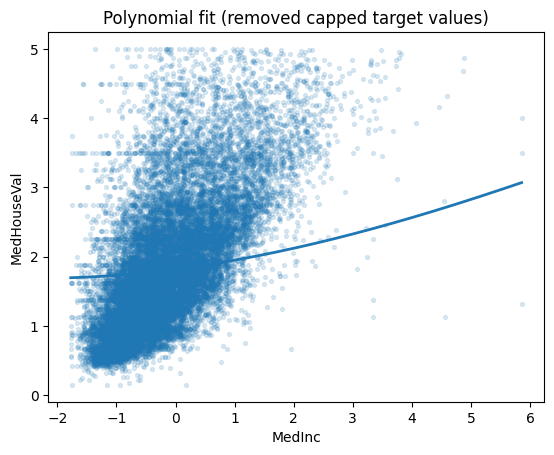

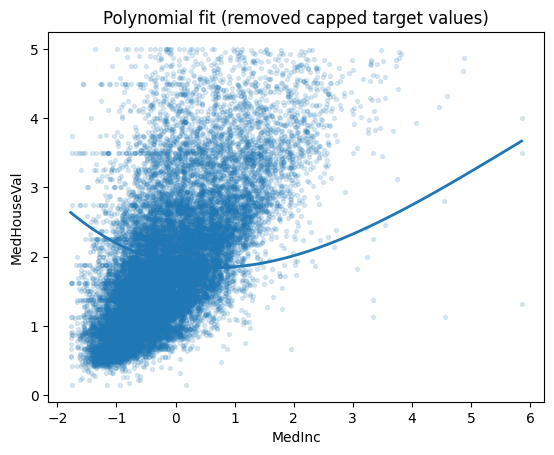

In [75]:
mask = y < y.max()
x2 = x_scaled[mask]
y2 = y[mask]

for p in range(1,5):
    fit = np.polyfit(x2, y2, p)

    xg = np.linspace(x2.min(), x2.max(), 500)
    yg = np.polyval(fit, xg)

    plt.scatter(x2, y2, alpha=0.15, s=8)
    plt.plot(xg, yg, linewidth=2)
    plt.xlabel("MedInc")
    plt.ylabel("MedHouseVal")
    plt.title("Polynomial fit (removed capped target values)")
    plt.show()


RankWarning pops up with higher degree polynomials since the range of MedInc causes huge numbers

In [77]:
def mse_kfold(x, y, p, k=5, seed=0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    rng = np.random.default_rng(seed)
    indices = rng.permutation(n)

    folds = np.array_split(indices, k)

    train_mses = []
    val_mses = []

    for fold_idx in range(k):
        val_idx = folds[fold_idx]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != fold_idx])

        x_train, y_train = x[train_idx], y[train_idx]
        x_val, y_val = x[val_idx], y[val_idx]

        train_mses.append(mse(x_train, y_train, p))

        fit = np.polyfit(x_train, y_train, p)
        beta_list = fit[::-1] 
        y_val_pred = yhat(x_val, beta_list)

        val_mses.append(np.mean((y_val - y_val_pred) ** 2))

    return float(np.mean(train_mses)), float(np.mean(val_mses))


In [73]:
polys = range(1, 6)
k = 8

train_mses = []
test_mses = []

for p in polys:
    train_mse, test_mse = mse_kfold(x, y, p=p, k=k)
    train_mses.append(train_mse)
    test_mses.append(test_mse)

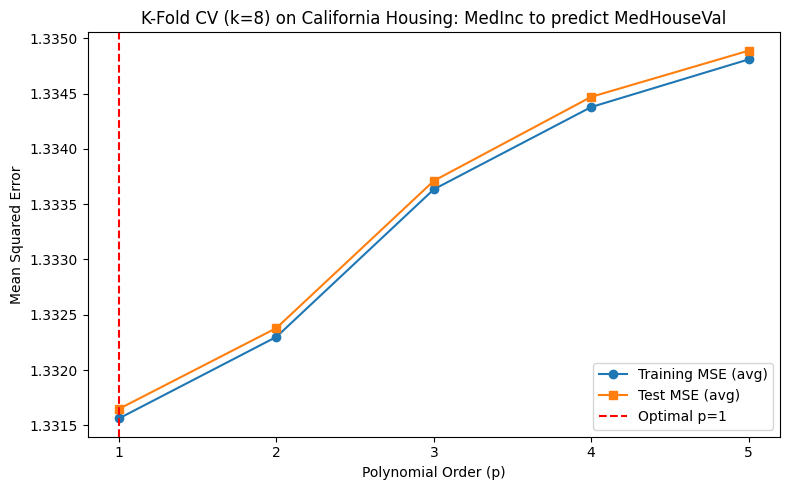

In [76]:
p_list = list(polys)
best_idx = np.argmin(test_mses)
best_p = p_list[best_idx]
plt.figure(figsize=(8, 5))
plt.plot(p_list, train_mses, 'o-', label='Training MSE (avg)')
plt.plot(p_list, test_mses, 's-', label='Test MSE (avg)')
plt.axvline(best_p, color='red', linestyle='--', label=f'Optimal p={best_p}')
plt.xlabel('Polynomial Order (p)')
plt.ylabel('Mean Squared Error')
plt.title(f'K-Fold CV (k={k}) on California Housing: MedInc to predict MedHouseVal')
plt.legend()
plt.xticks(p_list)
plt.tight_layout()
plt.show()

Polynomial order 1 is most optimal as it has the lowest mse and is the simplest model that fits the data well. It seems like median house values have a predominantly linear relationship with median income. An issue I came across was this dataset has values capped at $500k so we cannot see a trend for larger values and the curve tries to fit this ceiling.  The fit also is very sensitive to big outliers and will shift to acommodate those outliers that are high income low house value